## Intro

for this post, we are going to use the multi-modal LVLM model by meta: [llama3.2-vision](https://www.llama.com/docs/model-cards-and-prompt-formats/llama3_2/)

And we are going to load it up in 3 difference ways!!!

let's import all the packages we need and load an image to test the model!

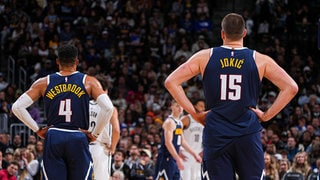

In [1]:
#| code-fold: false
import os, sys, base64, httpx
from PIL import Image
from io import BytesIO

import warnings
warnings.filterwarnings('ignore') # make blog post pretty ;)

image_url = "https://images2.9c9media.com/image_asset/2025_1_11_0c10be59-dad3-4f90-a1bd-087133dea6d2_jpg_1920x1080.jpg?width=320&height=180"
image_data = base64.b64encode(httpx.get(image_url).content).decode("utf-8")
pil_im = Image.open(BytesIO(httpx.get(image_url).content))
pil_im

### Prompt Template
let's create a prompt template that will be shared across the three different instances of the model

In [2]:
#| code-fold: false
from langchain_core.prompts import ChatPromptTemplate

template_message = [
        ("user",
            [
                {'type': 'text', 
                 'text': "please describe this image and list out all the numbers and name seen. \
                         no need to identify the person, just tell me what can be read on their jersey"
                },
                {
                    "type": "image_url",
                    "image_url": {"url": "data:image/jpeg;base64,{image_data}"},
                }
            ],
        ),
    ]
prompt_template = ChatPromptTemplate.from_messages(template_message)
image_messages = prompt_template.format_messages(image_data = image_data)

## Ollama (local)

for how to setup ollama, see [this post](ollama.qmd). Also make sure you have ran `pip install langchain-ollama`

then we can pull our VLM using the CLI with `ollama pull llama3.2-vision`

which should install the `11b` params version. For all available versions, see [here](https://ollama.com/library/llama3.2-vision/tags)

In [3]:
#| code-fold: false
from langchain_ollama import ChatOllama
chat_ollama = ChatOllama(model = 'llama3.2-vision',temperature = 0.0)

the first time loading up the model from a cold start will be a bit slower, expect subsequent load to be noticably faster

In [10]:
#| code-fold: false
%%time
r_ollama = chat_ollama(image_messages)

CPU times: user 16.3 ms, sys: 12.2 ms, total: 28.4 ms
Wall time: 1min 10s


### results

In [11]:
#| code-fold: false
print(r_ollama.content)

The image shows a basketball player standing on the court with his hands on his hips.

* The number 4 is visible on the back of one player's jersey.
* The name "Westbrook" is written across the top of that same jersey.
* The number 15 is visible on the back of another player's jersey.
* The name "Jokic" is written across the top of that same jersey.


## OpenRouter (hosted)
OpenRouter is a hosted models aggregated and offers a [list of free models](https://openrouter.ai/models?max_price=0)!

they are nicely integrated into LangChain using the OpenAI framework, so make sure you also `pip install langchain-openai`

In [13]:
#| code-fold: false
#| output: false
from langchain.chat_models import ChatOpenAI
chat_llama = ChatOpenAI(
    openai_api_key= os.environ.get("OPENROUTER_KEY"),
    openai_api_base= "https://openrouter.ai/api/v1",
    model_name="meta-llama/llama-3.2-11b-vision-instruct:free",
    temperature = 0.0
)

/var/folders/n9/x0btfm254xbbmffp_3k6lz_h0000gp/T/ipykernel_10544/4054560070.py:3: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  chat_llama = ChatOpenAI(


In [14]:
#| code-fold: false
%%time
r_openrouter = chat_llama(image_messages)

CPU times: user 44.4 ms, sys: 16.6 ms, total: 60.9 ms
Wall time: 1.73 s


### results
noticibly different from ollama version's [output](#results)

In [15]:
#| code-fold: false
print(r_openrouter.content)

The image depicts a basketball game in progress, with two players standing on the court. The player on the left is wearing a jersey with the number "4" and the name "WESTBROOK" in yellow letters. The player on the right is wearing a jersey with the number "15" and the name "JOKIC" in yellow letters.

Here is a list of the numbers and names visible on the jerseys:

* 4 (on the left player's jersey)
* WESTBROOK (on the left player's jersey)
* 15 (on the right player's jersey)
* JOKIC (on the right player's jersey)

Note: The numbers and names are written in yellow letters on the jerseys.


## HuggingFace (hosted)
huggingface actually offers a [serverless inference API](https://huggingface.co/docs/api-inference/index) which made literally thousands of models available, and all you need is a free API key!

This makes them solid choice for any Data Scientist doing experiments!!!

make sure you first `pip install langchain-huggingface` and follow the official docs [here](https://python.langchain.com/docs/integrations/providers/huggingface/#llms)

Note that llama-3.2 is a [gated model](https://huggingface.co/docs/hub/models-gated). You will have to give up your personal information first on the [model card's page](https://huggingface.co/docs/hub/models-gated) before you could load the model.

In [20]:
#| code-fold: false
%%time
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.2-11B-Vision-Instruct",
    task="text-generation",
    do_sample=False,
    repetition_penalty=1.03,
    temperature = 0.0,
    huggingfacehub_api_token = os.environ.get("HUGGINGFACEHUB_API_TOKEN")
)

chat_hf_llama = ChatHuggingFace(llm=llm)

CPU times: user 246 ms, sys: 35.5 ms, total: 281 ms
Wall time: 391 ms


In [18]:
#| code-fold: false
%%time
r_hf_llama = chat_hf_llama(image_messages)

CPU times: user 7.15 ms, sys: 2.82 ms, total: 9.97 ms
Wall time: 4.94 s


### results
again different from [ollama's](#results) and [OpenRouter's](#results-1)

In [21]:
#| code-fold: false
print(r_hf_llama.content)

The image is a photograph of two top NBA player (Russell Westbrook & Nikola Jokic) with their backs to the camera. 

Key elements of the jerseys include:
- "Westbrook" (last name) and the number "4"
- "Jokic" ( last name) and the number "15"

In the background crowd of people are sitting attending the game. 

The image conveys a sense of professional superiority due to fact that it captures the two top NBA players.


## Conclusion

* LLM are huge (llama3.2-vision-11b used in this example is about 7.9GB on disk) but they can be made to run locally with [ollama](#ollama-local)
* we also explored 2 additional ways to load hosted (Open-Sourced) model as well. Both options are free and offer lower latency (just a simple API call).
* note that results for the same prompt do vary even when using the same underlying model and with `temperature=0.0`; The contextual difference is not big for the given [image example](#intro) but could be significant given specific image-type or prompt. **So make sure you test out your model's results qualitatively across different providers when developing your application!**